**PROJECT AKHIR MATA KULIAH DATA MINING - Classification Analysis of Drug Use Risk Based on Personality and
Demographic Factors Using Machine Learning Algorithm**

TEAM 7

1. ANDIKA FEBRIANTO (24031554018)
2. DIAN ROHMATUL ISLAM (24031554047)
3. AFIFAH (2403154202)

CLASS OF : 2024 A

LECTURERS : Moh. Khoridatul Huda, S.Pd., M.Si., Ph.D.

DEPARTMENT OF DATA SCIENCE - FMIPA UNESA

17 Mei 2026

Sumber Dataset:  
https://archive.ics.uci.edu/dataset/373/drug+consumption+quantified

## Import Library

In [1]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import LabelEncoder, StandardScaler

In [3]:
#Model
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [4]:
#Aprio
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [5]:
import warnings
warnings.filterwarnings("ignore")

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [6]:
!pip install ucimlrepo

## Load Data

In [7]:
from ucimlrepo import fetch_ucirepo
drug_consumption = fetch_ucirepo(id=373)

X = drug_consumption.data.features
y = drug_consumption.data.targets

In [8]:
df = pd.concat([X, y], axis=1)

df

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss,alcohol,amphet,amyl,benzos,caff,cannabis,choc,coke,crack,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-0.21712,-1.18084,CL5,CL2,CL0,CL2,CL6,CL0,CL5,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575,CL5,CL2,CL2,CL0,CL6,CL4,CL6,CL3,CL0,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148,CL6,CL0,CL0,CL0,CL6,CL3,CL4,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084,CL4,CL0,CL0,CL3,CL5,CL2,CL4,CL2,CL0,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575,CL4,CL1,CL1,CL0,CL6,CL3,CL6,CL0,CL0,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,-1.13788,0.88113,1.92173,CL5,CL0,CL0,CL0,CL4,CL5,CL4,CL0,CL0,CL0,CL0,CL0,CL3,CL3,CL0,CL0,CL0,CL0,CL5
1881,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,-1.51840,0.88113,0.76540,CL5,CL0,CL0,CL0,CL5,CL3,CL4,CL0,CL0,CL2,CL0,CL0,CL3,CL5,CL4,CL4,CL5,CL0,CL0
1882,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,-1.38502,0.52975,-0.52593,CL4,CL6,CL5,CL5,CL6,CL6,CL6,CL4,CL0,CL4,CL0,CL2,CL0,CL2,CL0,CL2,CL6,CL0,CL0
1883,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,0.91093,-1.92173,0.29338,-1.62090,-2.57309,1.29221,1.22470,CL5,CL0,CL0,CL0,CL6,CL6,CL5,CL0,CL0,CL3,CL0,CL0,CL3,CL3,CL0,CL3,CL4,CL0,CL0


## Data Understanding

Informasi Dataset

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 31 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        1885 non-null   float64
 1   gender     1885 non-null   float64
 2   education  1885 non-null   float64
 3   country    1885 non-null   float64
 4   ethnicity  1885 non-null   float64
 5   nscore     1885 non-null   float64
 6   escore     1885 non-null   float64
 7   oscore     1885 non-null   float64
 8   ascore     1885 non-null   float64
 9   cscore     1885 non-null   float64
 10  impuslive  1885 non-null   float64
 11  ss         1885 non-null   float64
 12  alcohol    1885 non-null   object 
 13  amphet     1885 non-null   object 
 14  amyl       1885 non-null   object 
 15  benzos     1885 non-null   object 
 16  caff       1885 non-null   object 
 17  cannabis   1885 non-null   object 
 18  choc       1885 non-null   object 
 19  coke       1885 non-null   object 
 20  crack   

Statistika Deskriptif

In [10]:
print(df.describe())

              age       gender    education      country    ethnicity  \
count  1885.00000  1885.000000  1885.000000  1885.000000  1885.000000   
mean      0.03461    -0.000256    -0.003806     0.355542    -0.309577   
std       0.87836     0.482588     0.950078     0.700335     0.166226   
min      -0.95197    -0.482460    -2.435910    -0.570090    -1.107020   
25%      -0.95197    -0.482460    -0.611130    -0.570090    -0.316850   
50%      -0.07854    -0.482460    -0.059210     0.960820    -0.316850   
75%       0.49788     0.482460     0.454680     0.960820    -0.316850   
max       2.59171     0.482460     1.984370     0.960820     1.907250   

            nscore       escore       oscore       ascore       cscore  \
count  1885.000000  1885.000000  1885.000000  1885.000000  1885.000000   
mean      0.000047    -0.000163    -0.000534    -0.000245    -0.000386   
std       0.998106     0.997448     0.996229     0.997440     0.997523   
min      -3.464360    -3.273930    -3.273930  

## Preprocessing

Cek Missing Values

In [11]:
df.isnull().sum()

,0
age,0
gender,0
education,0
country,0
ethnicity,0
nscore,0
escore,0
oscore,0
ascore,0
cscore,0


Cek Duplikasi Data

In [12]:
df.duplicated().sum()

np.int64(0)

Transformasi Target

In [13]:
df["cannabis"] = df["cannabis"].replace({
    "CL0": 0,
    "CL1": 0,
    "CL2": 0,
    "CL3": 1,
    "CL4": 1,
    "CL5": 1,
    "CL6": 1
})

print(df["cannabis"].value_counts())

cannabis
1    999
0    886
Name: count, dtype: int64


Encoding Variable Kategorik

In [14]:
drug_cols = [
    "alcohol",
    "amphet",
    "amyl",
    "benzos",
    "caff",
    "choc",
    "coke",
    "crack",
    "ecstasy",
    "heroin",
    "ketamine",
    "legalh",
    "lsd",
    "meth",
    "mushrooms",
    "nicotine",
    "semer",
    "vsa"
]

mapping = {
    "CL0": 0,
    "CL1": 0,
    "CL2": 0,
    "CL3": 1,
    "CL4": 1,
    "CL5": 1,
    "CL6": 1
}

for col in drug_cols:
    df[col] = df[col].map(mapping)

print(df[drug_cols].head())

   alcohol  amphet  amyl  benzos  caff  choc  coke  crack  ecstasy  heroin  \
0        1       0     0       0     1     1     0      0        0       0   
1        1       0     0       0     1     1     1      0        1       0   
2        1       0     0       0     1     1     0      0        0       0   
3        1       0     0       1     1     1     0      0        0       0   
4        1       0     0       0     1     1     0      0        0       0   

   ketamine  legalh  lsd  meth  mushrooms  nicotine  semer  vsa  
0         0       0    0     0          0         0      0    0  
1         0       0    0     1          0         1      0    0  
2         0       0    0     0          0         0      0    0  
3         0       0    0     0          0         0      0    0  
4         0       0    0     0          0         0      0    0  


In [15]:
le = LabelEncoder()

categorical_cols = ["gender"]

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

Pisah Fitur dan Target

In [16]:
X = df.drop(columns=["cannabis"])
y = df["cannabis"]

In [17]:
X

,age,gender,education,country,ethnicity,nscore,escore,oscore,ascore,cscore,impuslive,ss,alcohol,amphet,amyl,benzos,caff,choc,coke,crack,ecstasy,heroin,ketamine,legalh,lsd,meth,mushrooms,nicotine,semer,vsa
0,0.49788,1,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,-0.21712,-1.18084,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
1,-0.07854,0,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,-0.71126,-0.21575,1,0,0,0,1,1,1,0,1,0,0,0,0,1,0,1,0,0
2,0.49788,0,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,-1.37983,0.40148,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
3,-0.95197,1,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,-1.37983,-1.18084,1,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0
4,0.49788,1,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,-0.21712,-0.21575,1,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,-0.95197,1,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,-1.13788,0.88113,1.92173,1,0,0,0,1,1,0,0,0,0,0,1,1,0,0,0,0,1
1881,-0.95197,0,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,-1.51840,0.88113,0.76540,1,0,0,0,1,1,0,0,0,0,0,1,1,1,1,1,0,0
1882,-0.07854,1,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,-1.38502,0.52975,-0.52593,1,1,1,1,1,1,1,0,1,0,0,0,0,0,0,1,0,0
1883,-0.95197,1,-0.61113,-0.57009,-0.31685,0.91093,-1.92173,0.29338,-1.62090,-2.57309,1.29221,1.22470,1,0,0,0,1,1,0,0,1,0,0,1,1,0,1,1,0,0


In [18]:
y

,cannabis
0,0
1,1
2,1
3,0
4,1
...,...
1880,1
1881,1
1882,1
1883,1


Standarisasi Data

In [19]:
le = LabelEncoder()
categorical_cols_X = X.select_dtypes(include="object").columns

for col in categorical_cols_X:
    X[col] = le.fit_transform(X[col])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Train Test Split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## EDA

Distribusi Data

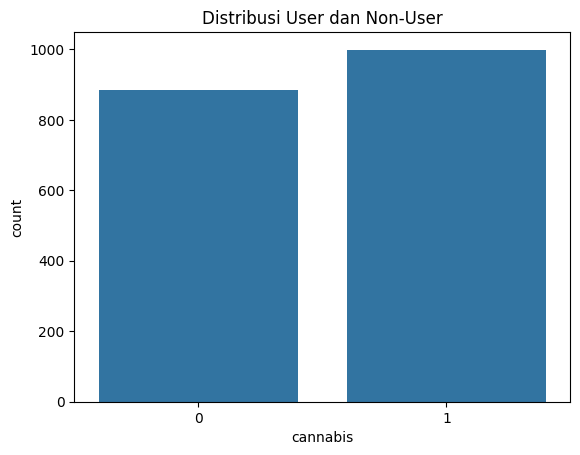

In [21]:
sns.countplot(x=y)
plt.title("Distribusi User dan Non-User")
plt.show()

Korelasi Antar Fitur

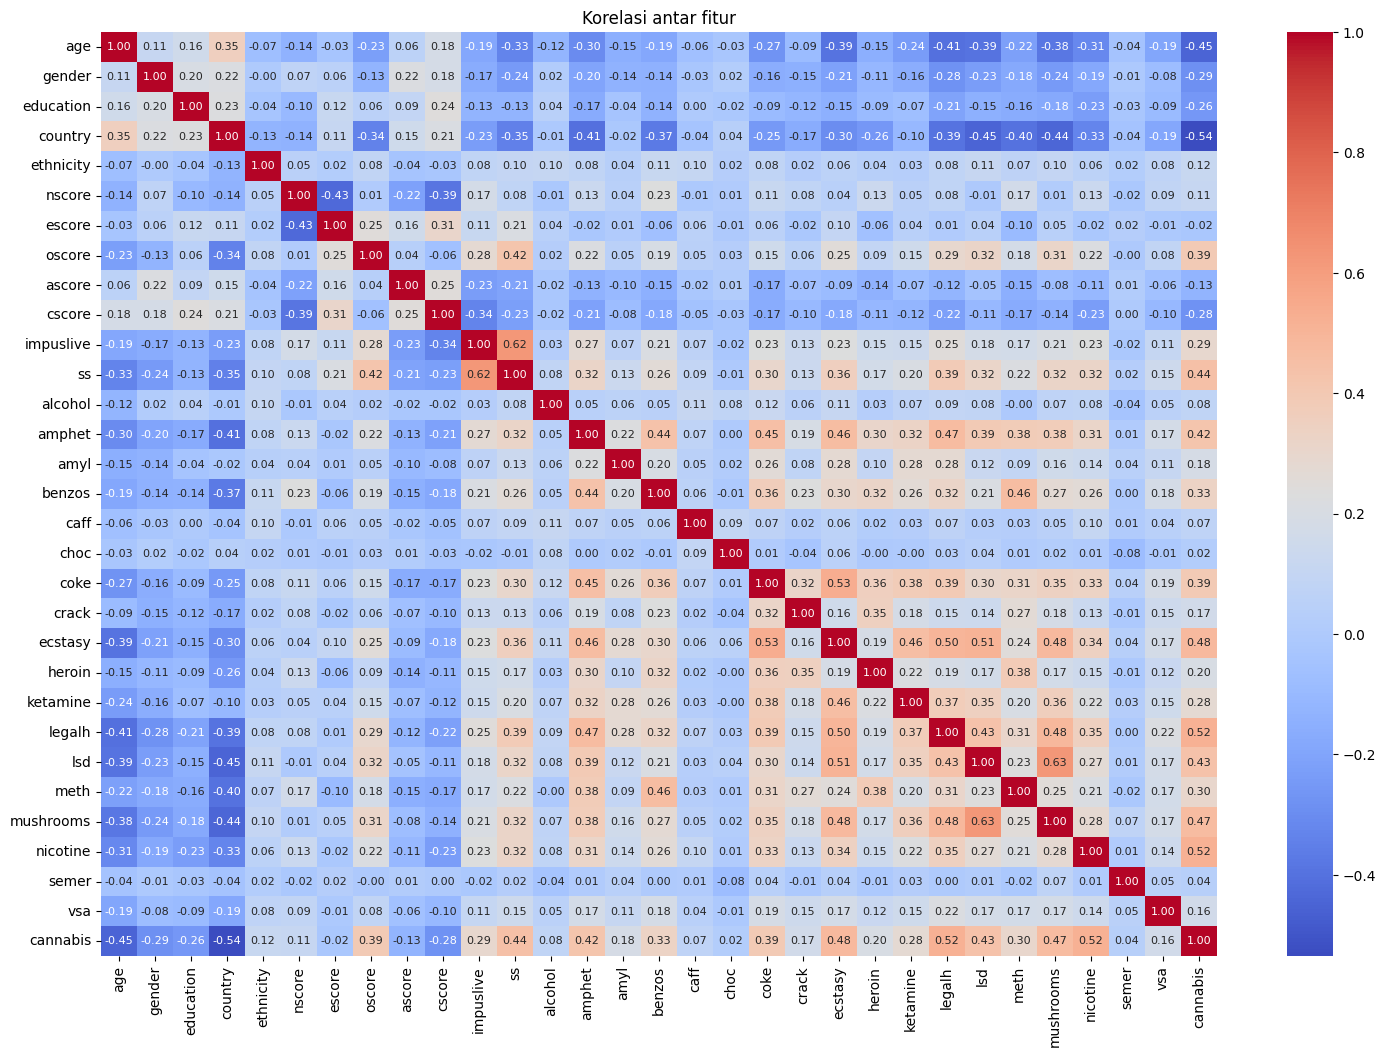

In [22]:
plt.figure(figsize=(18,12))
df_for_corr = pd.concat([X, y], axis=1)

sns.heatmap(
    df_for_corr.corr(),
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    annot_kws={"size":8}
)

plt.title("Korelasi antar fitur")
plt.show()

Distribusi Personality Traits

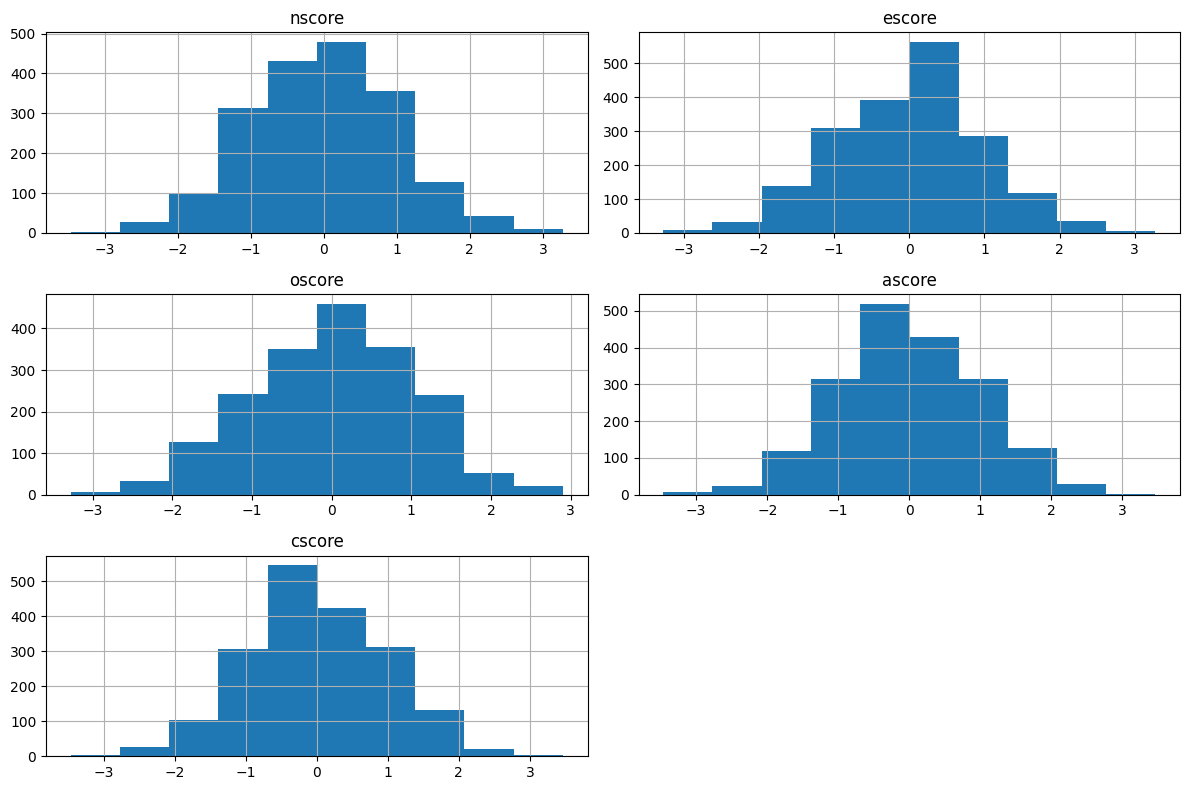

In [23]:
traits = ["nscore","escore","oscore","ascore","cscore"]

df[traits].hist(figsize=(12,8))

plt.tight_layout()
plt.show()

Analisis Boxplot Personality Traits

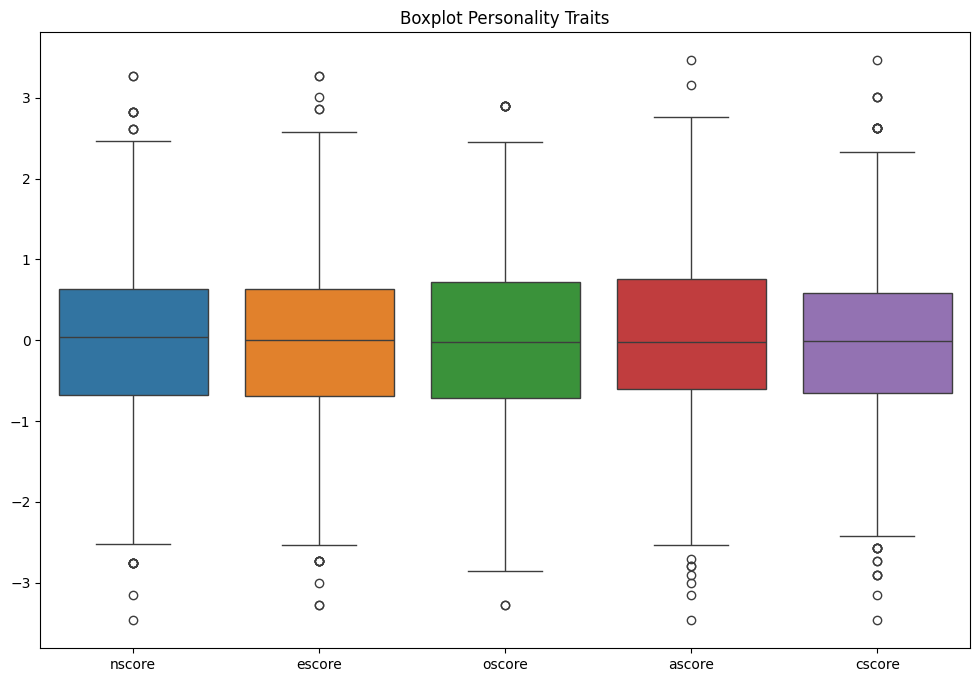

In [24]:
plt.figure(figsize=(12,8))

sns.boxplot(data=df[traits])

plt.title("Boxplot Personality Traits")
plt.show()

## Association Rule Mining

Transform Data ke Bentuk Biner

In [25]:
drug_cols = [
    "alcohol","cannabis","coke",
    "ecstasy","heroin"
]

basket = df[drug_cols]
basket = basket.astype(bool)

Apriori

In [26]:
frequent_itemsets = apriori(
    basket,
    min_support=0.05,
    use_colnames=True
)

print(frequent_itemsets.head())

    support    itemsets
0  0.927851   (alcohol)
1  0.529973  (cannabis)
2  0.221220      (coke)
3  0.274271   (ecstasy)
4  0.062599    (heroin)


Association Rules

In [27]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.6
)

print(rules[["antecedents","consequents","support","confidence","lift"]])

                  antecedents                   consequents   support  \
0                  (cannabis)                     (alcohol)  0.501857   
1                      (coke)                     (alcohol)  0.218568   
2                   (ecstasy)                     (alcohol)  0.266844   
3                    (heroin)                     (alcohol)  0.059947   
4                      (coke)                    (cannabis)  0.198408   
5                   (ecstasy)                    (cannabis)  0.253050   
6                    (heroin)                    (cannabis)  0.057294   
7                      (coke)                     (ecstasy)  0.159682   
8            (cannabis, coke)                     (alcohol)  0.195756   
9             (alcohol, coke)                    (cannabis)  0.195756   
10                     (coke)           (cannabis, alcohol)  0.195756   
11        (cannabis, ecstasy)                     (alcohol)  0.246684   
12         (alcohol, ecstasy)                    (c

## Modeling

Logistic Regression

In [28]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

Decission Tree

In [29]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

Random Forest

In [30]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

## Hasil Klasifikasi Prediksi

Logistic Regression

In [31]:
y_pred_lr = lr.predict(X_test)

print("Hasil Prediksi Logistic Regression")
print(y_pred_lr[:20])

Hasil Prediksi Logistic Regression
[1 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 1 1 0 1]


Decission Tree

In [32]:
y_pred_dt = dt.predict(X_test)

print("Hasil Prediksi Decision Tree")
print(y_pred_dt[:20])

Hasil Prediksi Decision Tree
[1 1 0 1 0 0 1 0 1 1 1 1 0 0 0 0 1 1 0 1]


Random Forest

In [33]:
y_pred_rf = rf.predict(X_test)

print("Hasil Prediksi Random Forest")
print(y_pred_rf[:20])

Hasil Prediksi Random Forest
[1 1 0 1 1 0 1 1 1 1 1 1 0 0 0 0 1 1 0 1]


## Evaluasi Model

In [34]:
def evaluate_model(y_test, y_pred, model_name):

    print(f"{model_name}")

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1-Score :", f1)

    print("classification Report")
    print(classification_report(y_test, y_pred))

In [35]:
def plot_confusion_matrix(y_test, y_pred, model_name):
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [36]:
evaluate_model(y_test, y_pred_lr, "Logistic Regression")

evaluate_model(y_test, y_pred_dt, "Decision Tree")

evaluate_model(y_test, y_pred_rf, "Random Forest")

Logistic Regression
Accuracy : 0.8673740053050398
Precision: 0.875
Recall   : 0.875
F1-Score : 0.875
classification Report
              precision    recall  f1-score   support

           0       0.86      0.86      0.86       177
           1       0.88      0.88      0.88       200

    accuracy                           0.87       377
   macro avg       0.87      0.87      0.87       377
weighted avg       0.87      0.87      0.87       377

Decision Tree
Accuracy : 0.8116710875331565
Precision: 0.7972350230414746
Recall   : 0.865
F1-Score : 0.829736211031175
classification Report
              precision    recall  f1-score   support

           0       0.83      0.75      0.79       177
           1       0.80      0.86      0.83       200

    accuracy                           0.81       377
   macro avg       0.81      0.81      0.81       377
weighted avg       0.81      0.81      0.81       377

Random Forest
Accuracy : 0.8594164456233422
Precision: 0.8483412322274881
Recall 

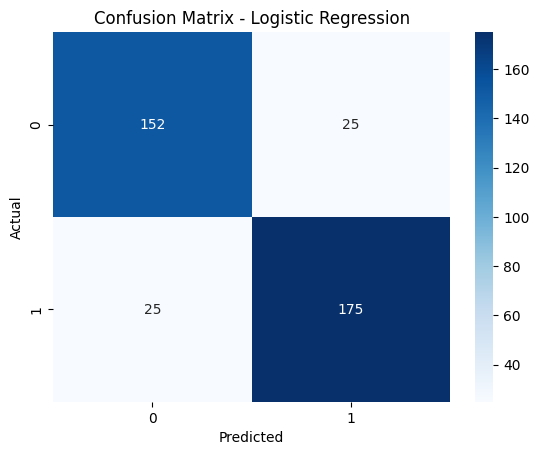

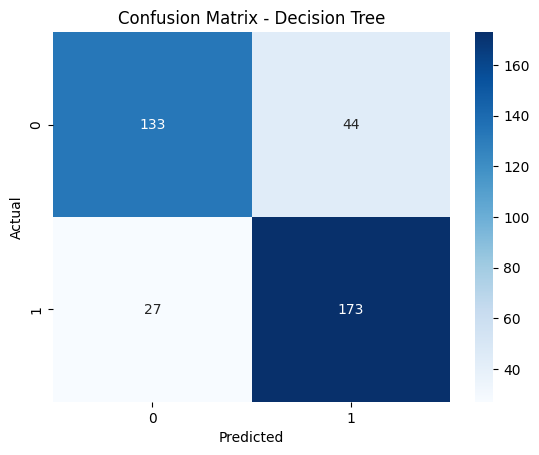

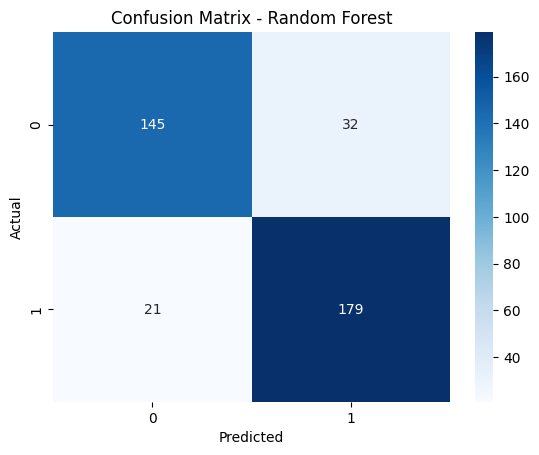

In [37]:
# Logistic Regression
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")

# Decision Tree
plot_confusion_matrix(y_test, y_pred_dt, "Decision Tree")

# Random Forest
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")

## ROC-AUC

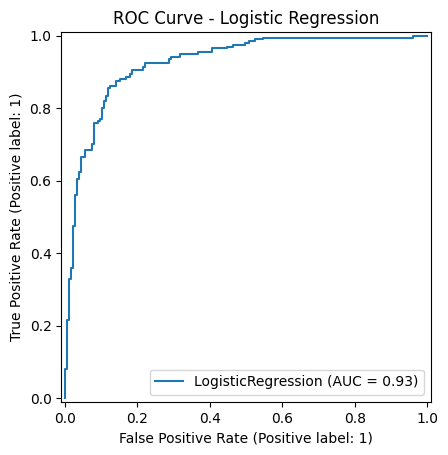

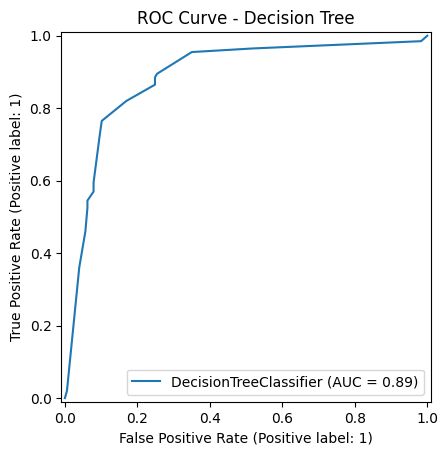

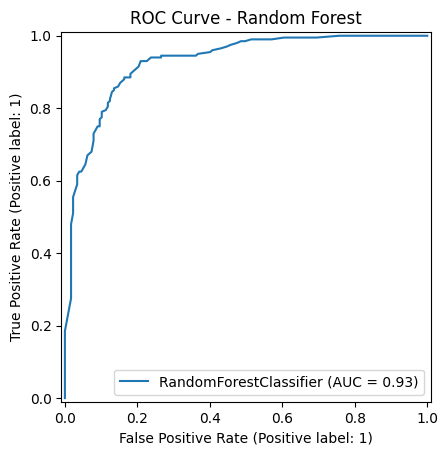

In [38]:
RocCurveDisplay.from_estimator(lr, X_test, y_test)
plt.title("ROC Curve - Logistic Regression")
plt.show()

RocCurveDisplay.from_estimator(dt, X_test, y_test)
plt.title("ROC Curve - Decision Tree")
plt.show()

RocCurveDisplay.from_estimator(rf, X_test, y_test)
plt.title("ROC Curve - Random Forest")
plt.show()

## Feature Importance Random Forest

      Feature  Importance
3     country    0.114530
23     legalh    0.106920
27   nicotine    0.091913
20    ecstasy    0.065032
0         age    0.063587
11         ss    0.057135
7      oscore    0.056035
9      cscore    0.051061
26  mushrooms    0.047874
5      nscore    0.043352
6      escore    0.042140
8      ascore    0.038914
13     amphet    0.036298
2   education    0.032727
10  impuslive    0.030377
18       coke    0.028611
24        lsd    0.018299
15     benzos    0.015486
1      gender    0.013950
25       meth    0.010120
14       amyl    0.006450
12    alcohol    0.005987
4   ethnicity    0.005472
22   ketamine    0.004162
21     heroin    0.003828
17       choc    0.003194
29        vsa    0.002744
19      crack    0.002244
16       caff    0.001558
28      semer    0.000000


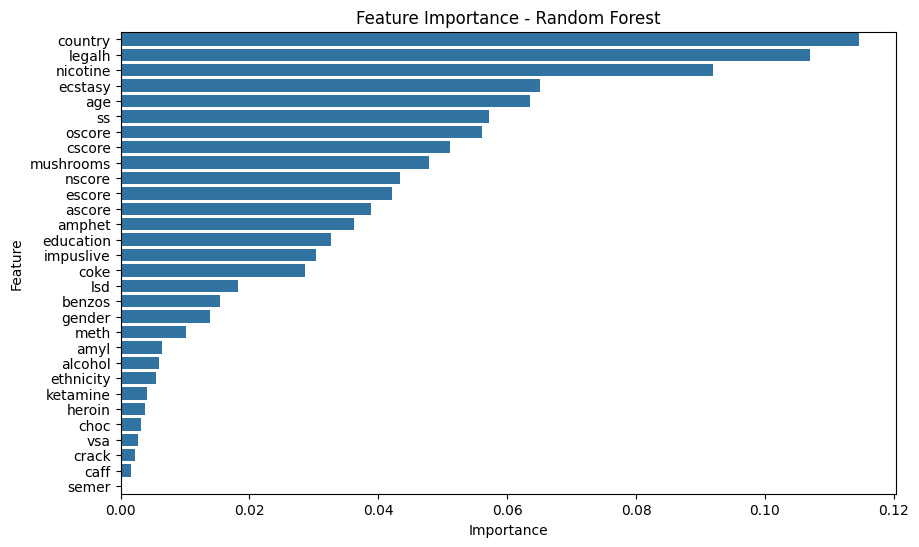

In [39]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance - Random Forest")
plt.show()

## Perbandingan Model

In [40]:
results = pd.DataFrame({
    "Model": ["Logistic Regression",
              "Decision Tree",
              "Random Forest"],

    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ]
})

print(results)

                 Model  Accuracy
0  Logistic Regression  0.867374
1        Decision Tree  0.811671
2        Random Forest  0.859416


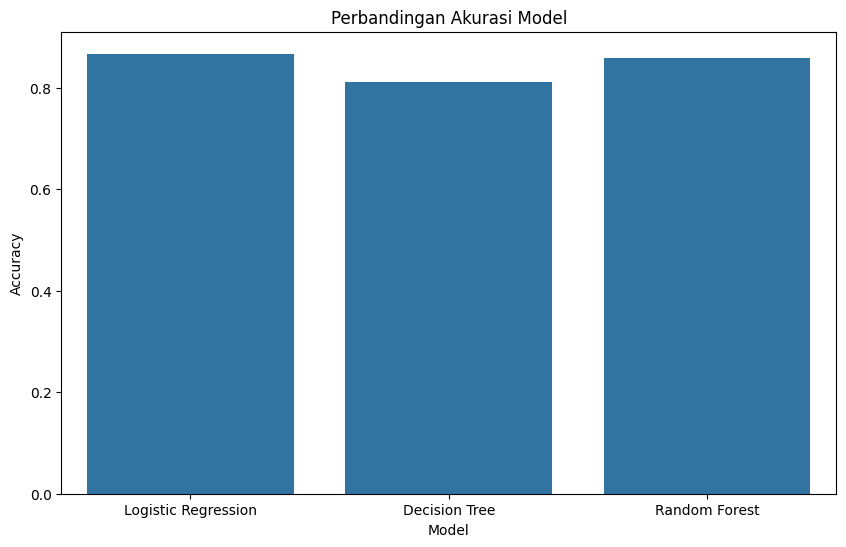

In [41]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=results
)

plt.title("Perbandingan Akurasi Model")
plt.show()